# Compare prototype and current exchangeability benchmarks

This notebook compares `df_raw_exp_results_n=1000_MC=50.csv` with the results
produced by `exchangeability_test_benchmark.ipynb`.

Both benchmarks now use the same five generator definitions, binary task, and
1,000 test observations per run. The six methods below are matched to their
public-API successors. The historical CSV contains 50 unseeded runs; the current
benchmark contains 5 deterministic runs and uses a smaller permutation budget.
The comparison therefore isolates the scenarios and sample size, but it is not
yet a paired test on identical realized samples.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "df_raw_exp_results_n=1000_MC=50.csv").exists():
    NOTEBOOK_DIR = Path("notebooks/echangeability_test")

HISTORICAL_RESULTS_PATH = (
    NOTEBOOK_DIR / "df_raw_exp_results_n=1000_MC=50.csv"
)
CURRENT_RESULTS_PATH = (
    NOTEBOOK_DIR / "df_current_api_results_n=1000_MC=5.csv"
)

assert HISTORICAL_RESULTS_PATH.exists(), "Historical results CSV is missing."
assert CURRENT_RESULTS_PATH.exists(), (
    "Run exchangeability_test_benchmark.ipynb before this comparison notebook."
)

## Load and align both result tables

In [2]:
historical_results = pd.read_csv(HISTORICAL_RESULTS_PATH)
historical_results = historical_results.drop(
    columns=[column for column in historical_results if column.startswith("Unnamed:")]
)
current_results = pd.read_csv(CURRENT_RESULTS_PATH)

METHOD_MAP = {
    "permutation_pvalue": "pvalue_permutation",
    "binomial_martingale_test": "permutation_binomial",
    "binomial_mixture_martingale_test": "permutation_binomial_mixture",
    "aggressive_martingale_test": "permutation_aggressive",
    "plugin_martingale": "plugin_martingale",
    "jumper_martingale": "jumper_martingale",
}

METHOD_ORDER = list(METHOD_MAP.values())
SCENARIO_ORDER = [
    "exchangeable",
    "two_gaussian_abrupt_shift",
    "generate_two_gaussian_slow_shift",
    "generate_var1_dependence",
    "generate_complex_dependence",
]
SCENARIO_LABELS = {
    "exchangeable": "Exchangeable Gaussian",
    "two_gaussian_abrupt_shift": "Two-Gaussian abrupt shift",
    "generate_two_gaussian_slow_shift": "Two-Gaussian slow shift",
    "generate_var1_dependence": "VAR(1) dependence",
    "generate_complex_dependence": "Complex dependence",
}

prototype = historical_results[
    historical_results["method"].isin(METHOD_MAP)
    & historical_results["scenario"].isin(SCENARIO_ORDER)
].copy()
prototype["method"] = prototype["method"].map(METHOD_MAP)
prototype["ground_truth"] = prototype["is_exchangeable_ground_truth"].astype(bool)
prototype["prediction"] = prototype["is_exchangeable"].astype(bool)
prototype["correct"] = prototype["prediction"] == prototype["ground_truth"]
prototype["benchmark"] = "Prototype: 50 runs"

current = current_results.copy()
current["ground_truth"] = current["ground_truth"].astype(bool)
current["prediction"] = current["prediction"].astype(bool)
current["correct"] = current["prediction"] == current["ground_truth"]
current["benchmark"] = "Current API: 5 runs"

COMPARABLE_COLUMNS = [
    "benchmark",
    "scenario",
    "method",
    "run",
    "ground_truth",
    "prediction",
    "correct",
]
comparison_results = pd.concat(
    [prototype[COMPARABLE_COLUMNS], current[COMPARABLE_COLUMNS]],
    ignore_index=True,
)

comparison_results.groupby("benchmark").size().rename("comparable rows")

benchmark
Current API: 5 runs     150
Prototype: 50 runs     1500
Name: comparable rows, dtype: int64

## Decision accuracy on matched scenario generators

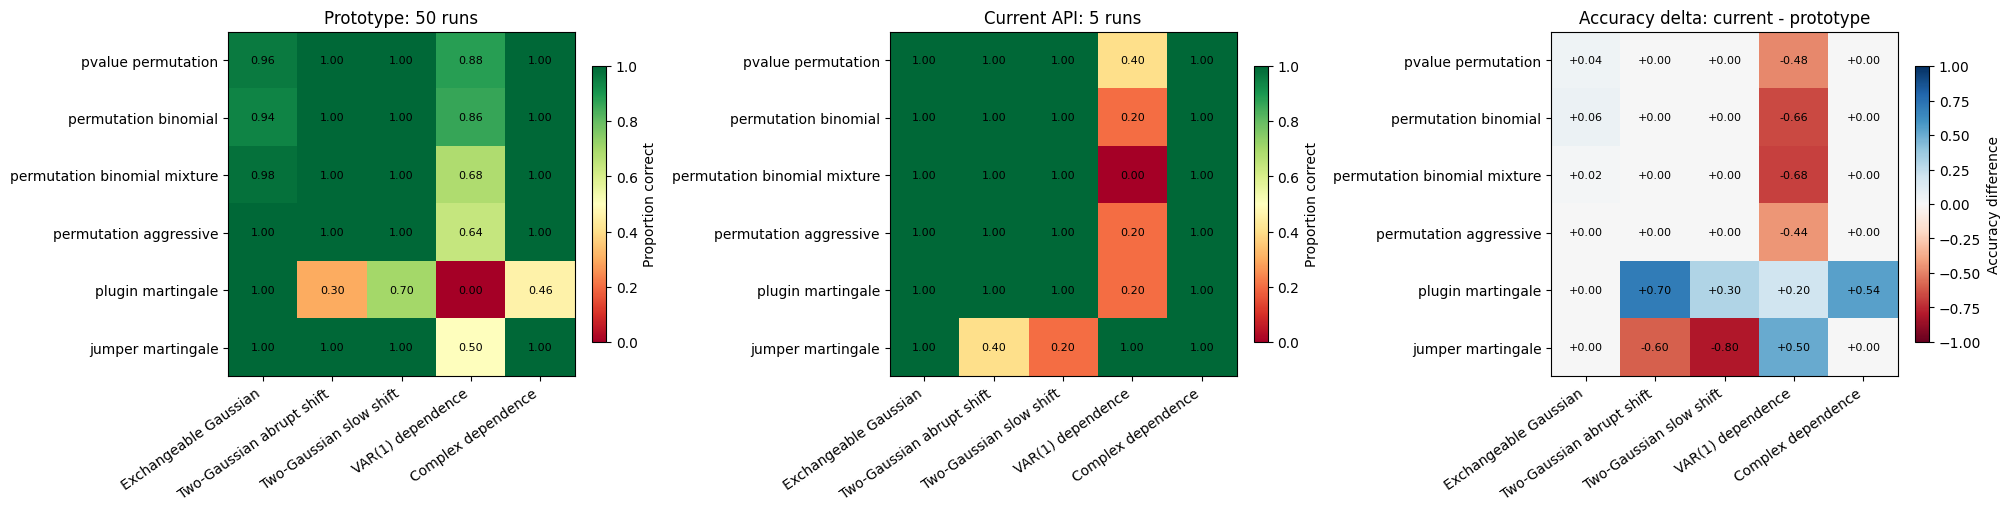

In [3]:
BENCHMARK_ORDER = ["Prototype: 50 runs", "Current API: 5 runs"]

accuracy_by_benchmark = {}
for benchmark in BENCHMARK_ORDER:
    accuracy_by_benchmark[benchmark] = (
        comparison_results[comparison_results["benchmark"] == benchmark]
        .groupby(["method", "scenario"])["correct"]
        .mean()
        .unstack("scenario")
        .reindex(index=METHOD_ORDER, columns=SCENARIO_ORDER)
    )

accuracy_delta = (
    accuracy_by_benchmark[BENCHMARK_ORDER[1]]
    - accuracy_by_benchmark[BENCHMARK_ORDER[0]]
)


def annotate_heatmap(ax, values, value_format):
    for row in range(values.shape[0]):
        for column in range(values.shape[1]):
            ax.text(
                column,
                row,
                value_format.format(values.iloc[row, column]),
                ha="center",
                va="center",
                fontsize=8,
            )


fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)
for ax, benchmark in zip(axes[:2], BENCHMARK_ORDER):
    values = accuracy_by_benchmark[benchmark]
    image = ax.imshow(values, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")
    annotate_heatmap(ax, values, "{:.2f}")
    ax.set_title(benchmark)
    fig.colorbar(image, ax=ax, label="Proportion correct", shrink=0.8)

delta_image = axes[2].imshow(
    accuracy_delta, vmin=-1, vmax=1, cmap="RdBu", aspect="auto"
)
annotate_heatmap(axes[2], accuracy_delta, "{:+.2f}")
axes[2].set_title("Accuracy delta: current - prototype")
fig.colorbar(delta_image, ax=axes[2], label="Accuracy difference", shrink=0.8)

for ax in axes:
    ax.set_xticks(
        range(len(SCENARIO_ORDER)),
        [SCENARIO_LABELS[name] for name in SCENARIO_ORDER],
        rotation=35,
        ha="right",
    )
    ax.set_yticks(
        range(len(METHOD_ORDER)),
        [method.replace("_", " ") for method in METHOD_ORDER],
    )

plt.show()

In [4]:
accuracy_comparison = pd.concat(
    {
        "prototype_accuracy": accuracy_by_benchmark[BENCHMARK_ORDER[0]].stack(),
        "current_accuracy": accuracy_by_benchmark[BENCHMARK_ORDER[1]].stack(),
        "delta": accuracy_delta.stack(),
    },
    axis=1,
).reset_index()

accuracy_comparison

,method,scenario,prototype_accuracy,current_accuracy,delta
0,pvalue_permutation,exchangeable,0.96,1.0,0.04
1,pvalue_permutation,two_gaussian_abrupt_shift,1.00,1.0,0.00
2,pvalue_permutation,generate_two_gaussian_slow_shift,1.00,1.0,0.00
3,pvalue_permutation,generate_var1_dependence,0.88,0.4,-0.48
4,pvalue_permutation,generate_complex_dependence,1.00,1.0,0.00
5,permutation_binomial,exchangeable,0.94,1.0,0.06
6,permutation_binomial,two_gaussian_abrupt_shift,1.00,1.0,0.00
7,permutation_binomial,generate_two_gaussian_slow_shift,1.00,1.0,0.00
8,permutation_binomial,generate_var1_dependence,0.86,0.2,-0.66
9,permutation_binomial,generate_complex_dependence,1.00,1.0,0.00


## False alarms and aggregate detection power

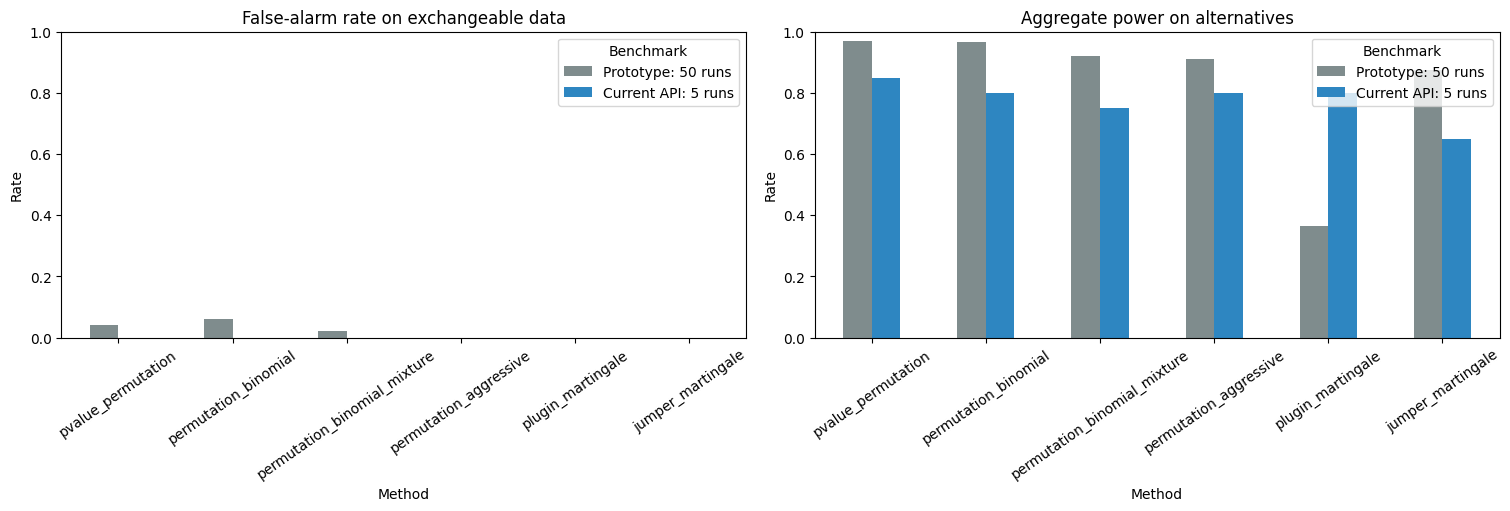

,benchmark,method,false_alarm_rate,aggregate_detection_power,exchangeable_decisions,alternative_decisions
0,Prototype: 50 runs,pvalue_permutation,0.04,0.970,50,200
1,Prototype: 50 runs,permutation_binomial,0.06,0.965,50,200
2,Prototype: 50 runs,permutation_binomial_mixture,0.02,0.920,50,200
3,Prototype: 50 runs,permutation_aggressive,0.00,0.910,50,200
4,Prototype: 50 runs,plugin_martingale,0.00,0.365,50,200
5,Prototype: 50 runs,jumper_martingale,0.00,0.875,50,200
6,Current API: 5 runs,pvalue_permutation,0.00,0.850,5,20
7,Current API: 5 runs,permutation_binomial,0.00,0.800,5,20
8,Current API: 5 runs,permutation_binomial_mixture,0.00,0.750,5,20
9,Current API: 5 runs,permutation_aggressive,0.00,0.800,5,20


In [5]:
summary_rows = []
for benchmark in BENCHMARK_ORDER:
    benchmark_results = comparison_results[
        comparison_results["benchmark"] == benchmark
    ].assign(rejected=lambda frame: ~frame["prediction"])
    for method in METHOD_ORDER:
        method_results = benchmark_results[benchmark_results["method"] == method]
        exchangeable = method_results[method_results["scenario"] == "exchangeable"]
        alternatives = method_results[method_results["scenario"] != "exchangeable"]
        summary_rows.append(
            {
                "benchmark": benchmark,
                "method": method,
                "false_alarm_rate": exchangeable["rejected"].mean(),
                "aggregate_detection_power": alternatives["rejected"].mean(),
                "exchangeable_decisions": len(exchangeable),
                "alternative_decisions": len(alternatives),
            }
        )

operating_characteristics = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for ax, metric, title in [
    (axes[0], "false_alarm_rate", "False-alarm rate on exchangeable data"),
    (axes[1], "aggregate_detection_power", "Aggregate power on alternatives"),
]:
    pivot = (
        operating_characteristics.pivot(index="method", columns="benchmark", values=metric)
        .reindex(index=METHOD_ORDER, columns=BENCHMARK_ORDER)
    )
    pivot.plot(kind="bar", ax=ax, color=["#7F8C8D", "#2E86C1"])
    ax.set_title(title)
    ax.set_xlabel("Method")
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Benchmark")

plt.show()

operating_characteristics

The historical samples themselves cannot be paired because the CSV stores
only results and the old benchmark did not record seeds. A fully paired comparison
would require rerunning the prototype methods and current methods together on each
newly seeded dataset. This notebook nevertheless removes the previous task,
scenario, and sample-size mismatch.